In [2]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR

# Load data using config paths
df = pd.read_csv(RAW_DATA_DIR / "IT_SystemPerformanceAndResourceMetricsDataset.csv")

print(df.shape)

df.head()

(100000, 12)


,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status
0,40.581311,43.627674,36.769917,127.990769,646.0,3230.0,1500.0,0.065837,82.782403,255.012964,715.803096,0
1,95.317859,39.962089,10.041088,92.399198,626.0,3130.0,243.0,0.123481,59.424540,81.204822,86.158314,0
2,74.539424,25.853852,17.985345,192.935206,101.0,303.0,229.0,0.025459,90.973363,210.685067,545.755982,0
3,61.872556,64.654000,33.500751,44.576712,52.0,156.0,1574.0,0.178884,37.344280,90.398182,541.918137,0
4,19.821771,52.896174,24.622378,117.983427,126.0,378.0,1164.0,0.167508,40.203942,87.099085,113.660688,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   cpu_utilization    100000 non-null  float64
 1   memory_usage       100000 non-null  float64
 2   disk_io            100000 non-null  float64
 3   network_latency    100000 non-null  float64
 4   process_count      100000 non-null  float64
 5   thread_count       100000 non-null  float64
 6   context_switches   100000 non-null  float64
 7   cache_miss_rate    100000 non-null  float64
 8   temperature        100000 non-null  float64
 9   power_consumption  100000 non-null  float64
 10  uptime             100000 non-null  float64
 11  status             100000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 9.2 MB


In [5]:
df.describe()

,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,52.080633,55.271806,25.485618,100.202214,517.366873,1813.869388,1034.909019,0.105863,62.339210,175.020452,500.208994,0.01010
std,27.313792,26.067433,14.076605,57.631647,275.344211,1170.173350,550.573776,0.055221,18.891567,71.825942,287.174223,0.09999
min,2.128513,8.048098,-0.231219,-3.608357,27.571294,-16.168082,51.972467,0.005529,28.440027,44.115174,-22.829151,0.00000
25%,28.496574,32.699681,13.365257,49.753810,276.696475,861.580989,551.662033,0.058077,46.020860,113.786390,250.522759,0.00000
50%,51.958406,55.354241,25.538738,100.629433,513.953615,1595.812934,1032.398621,0.105148,62.024666,173.831830,503.198852,0.00000
75%,75.518190,77.970439,37.528869,149.886386,756.434793,2602.159948,1506.135295,0.154716,78.951766,236.512648,746.889731,0.00000
max,102.230245,102.514872,51.335907,204.099826,1025.720420,5086.033438,2035.862804,0.204890,96.714745,306.214154,1025.602625,1.00000


In [6]:
df.isnull().sum()

cpu_utilization      0
memory_usage         0
disk_io              0
network_latency      0
process_count        0
thread_count         0
context_switches     0
cache_miss_rate      0
temperature          0
power_consumption    0
uptime               0
status               0
dtype: int64

Histogram

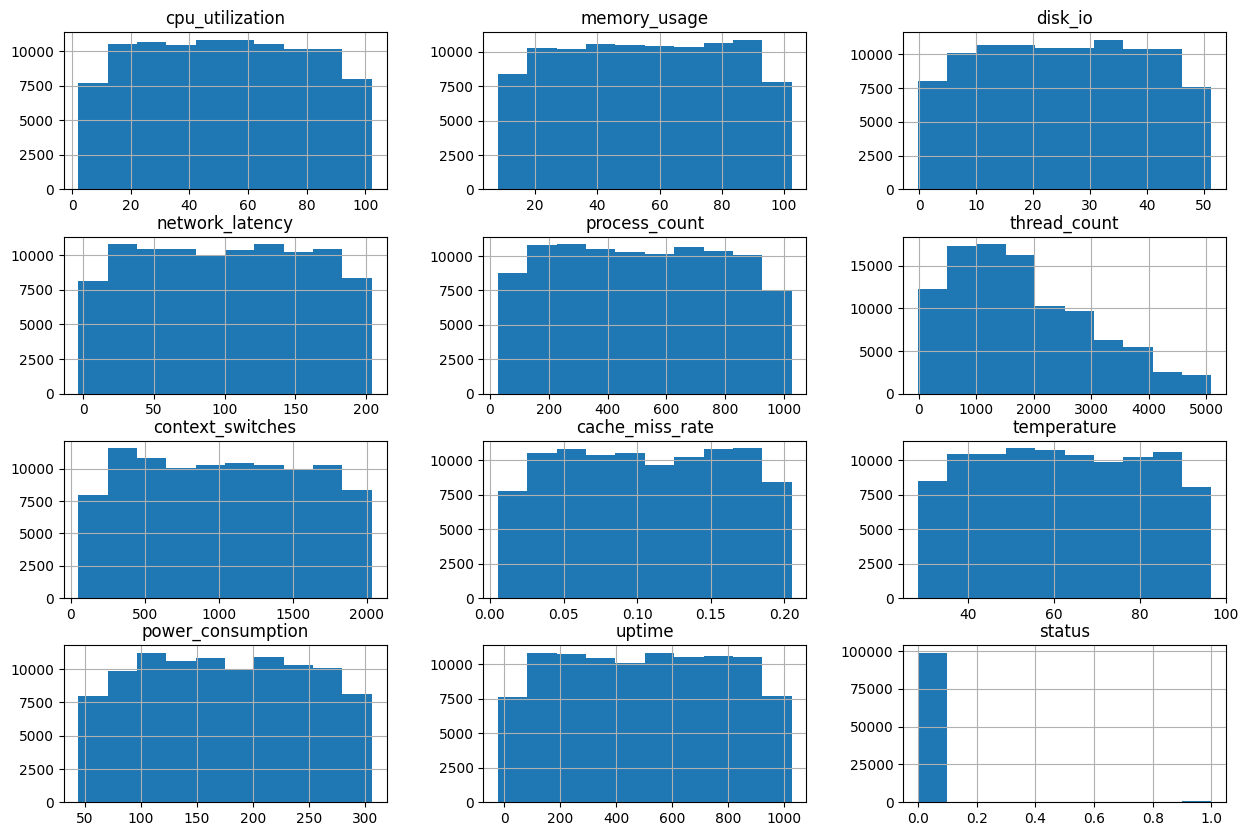

In [7]:
import matplotlib.pyplot as plt

df.hist(
    figsize=(15,10)
)

plt.show()

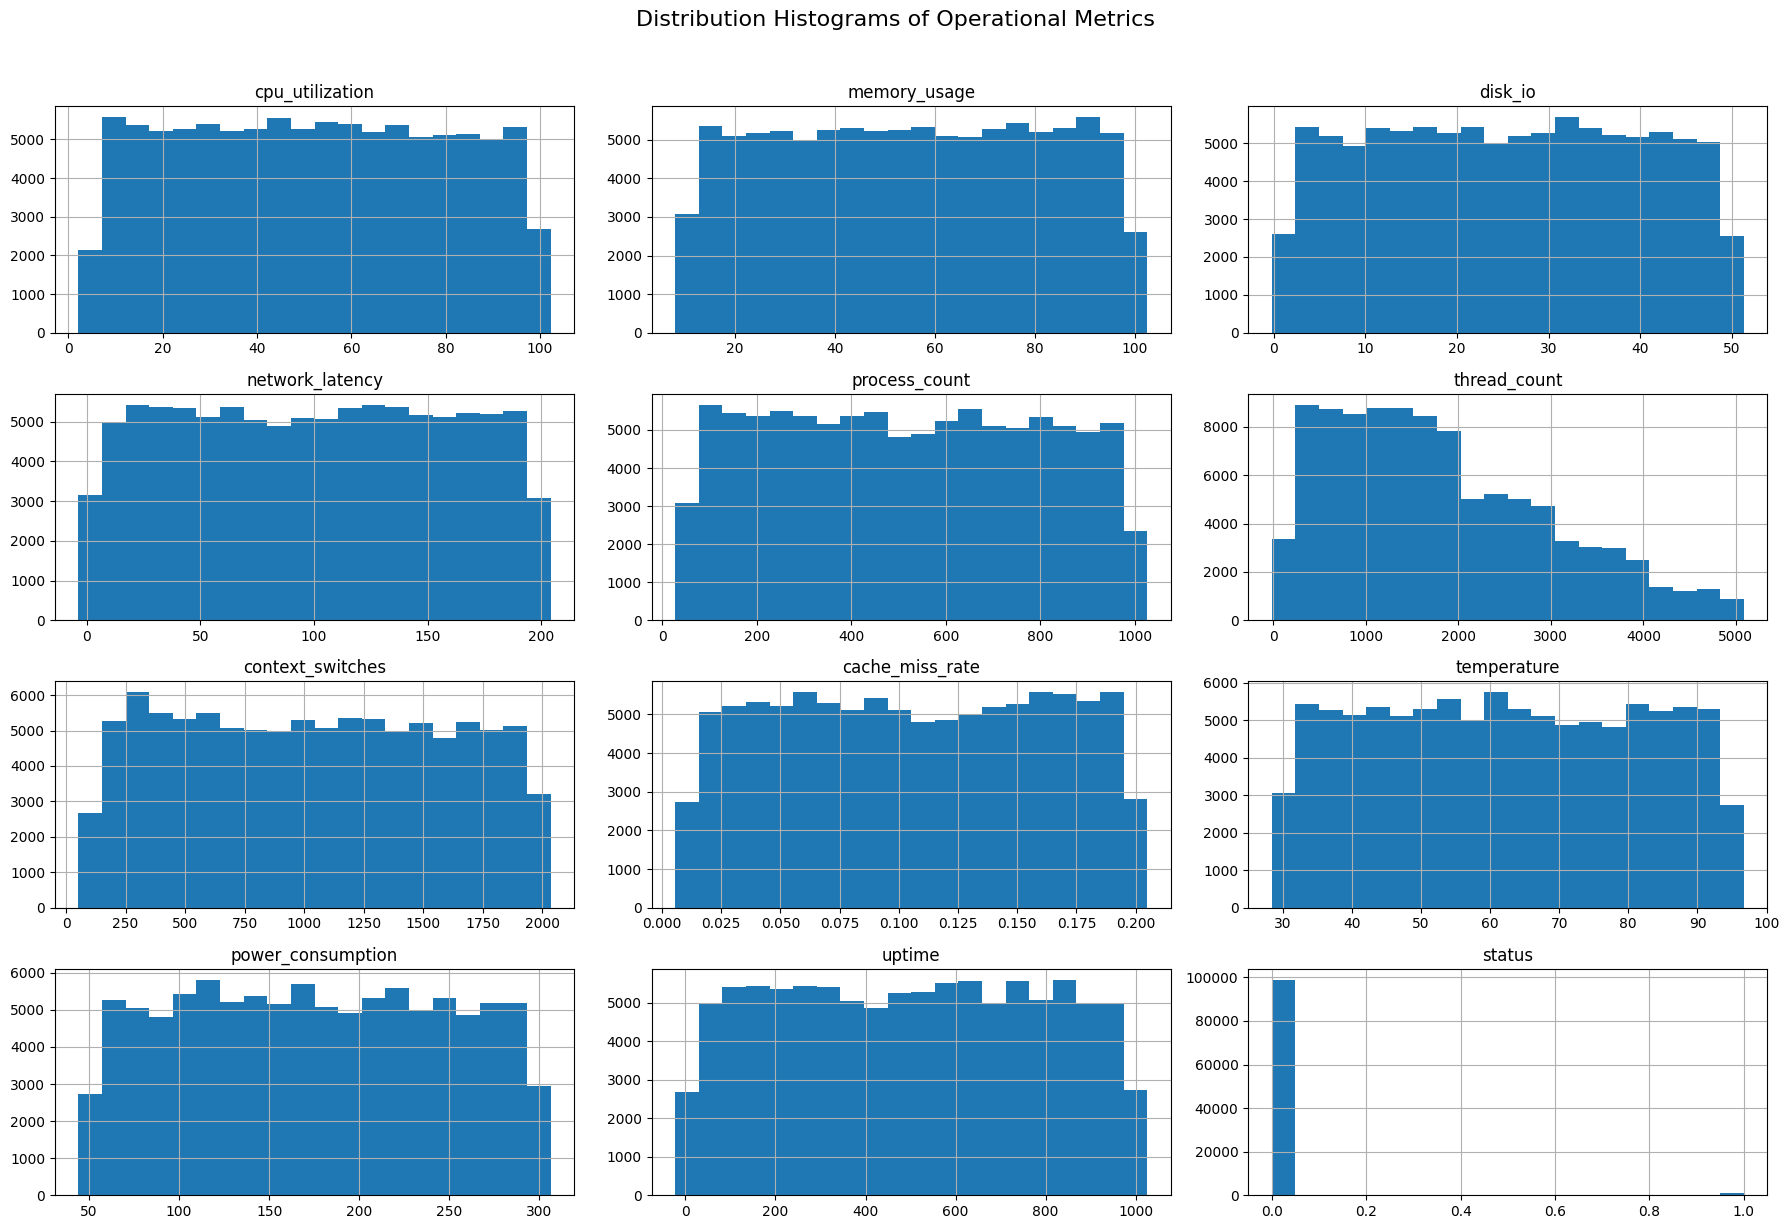

In [ ]:
import matplotlib.pyplot as plt

# Create histogram grid
df.hist(
    figsize=(18, 12),
    bins=20
)

plt.suptitle(
    "Distribution Histograms of Operational Metrics",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# Save Image using config path
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "eda_histograms.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Correlation Heatmap

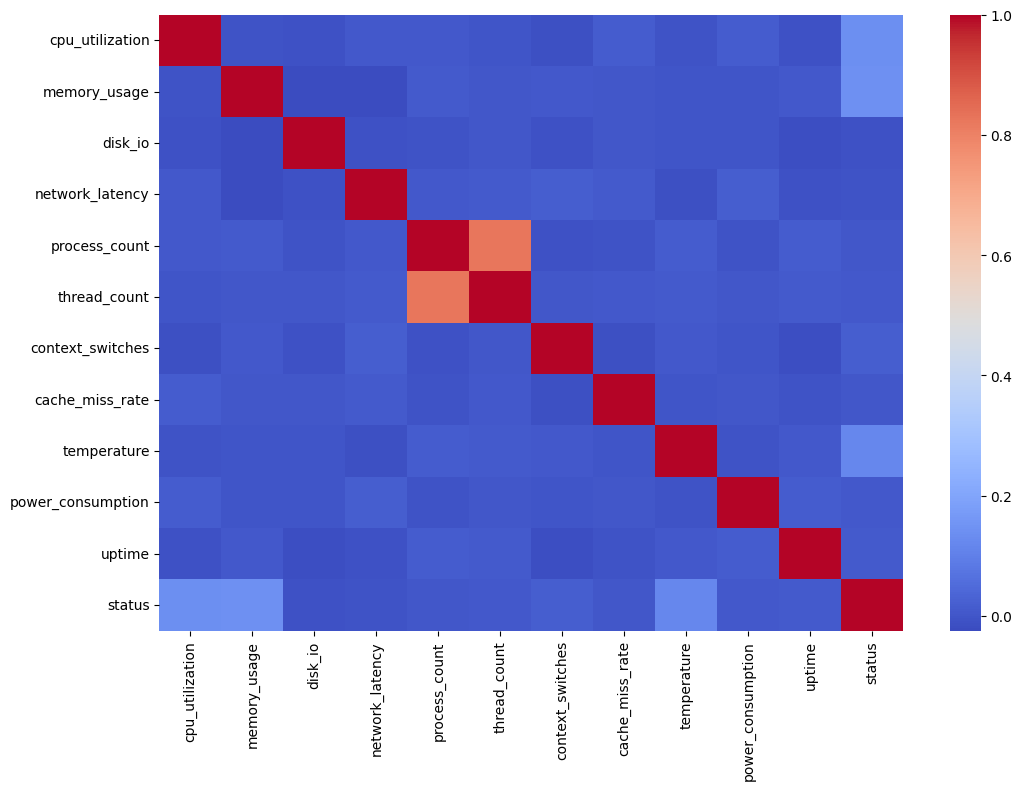

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.savefig(
    FIGURES_DIR / "correlation_heatmap.png"
)

plt.show()

In [ ]:
# Anomaly Distribution

# If anomaly label exists:

df['status'].value_counts()

KeyError: 'Anomaly'

In [ ]:
def risk_score(cpu,memory,latency):

    score = (
        0.4*(cpu/100)
        + 0.35*(memory/100)
        + 0.25*(latency/200)
    )

    return score

In [ ]:
def assign_risk(score):

    if score < 0.4:
        return "Low"

    elif score < 0.7:
        return "Medium"

    else:
        return "High"

In [ ]:
# Create the cleaned dataset
# Step1: Handle missing values

df.isnull().sum()

In [ ]:
# Step 2: Remove Duplicates

df.drop_duplicates(inplace=True)

In [ ]:
# Step 3: Check Shape

print(df.shape)

In [ ]:
# Step 4: Create Processed Folder using config path

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Step 5: Save Cleaned Dataset using config path

df.to_csv(
    PROCESSED_DATA_DIR / "cleaned_dataset.csv",
    index=False
)

In [ ]:
print(df.columns.tolist())

In [ ]:
df["status"].value_counts()